# Pulsar Star Detection using MLP
Implementation of a Multi-Layer Perceptron (MLP) to distinguish real pulsar stars from cosmic noise based on signal characteristics.

In [48]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data Analysis and Preprocessing

In [49]:
train_df = pd.read_csv('data\pulsar_data_train.csv')
test_df = pd.read_csv('data\pulsar_data_test.csv')

display(train_df.head())
display(train_df.describe())

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,121.156250,48.372971,0.375485,-0.013165,3.168896,18.399367,7.449874,65.159298,0.0
1,76.968750,36.175557,0.712898,3.388719,2.399666,17.570997,9.414652,102.722975,0.0
2,130.585938,53.229534,0.133408,-0.297242,2.743311,22.362553,8.508364,74.031324,0.0
3,156.398438,48.865942,-0.215989,-0.171294,17.471572,NaN,2.958066,7.197842,0.0
4,84.804688,36.117659,0.825013,3.274125,2.790134,20.618009,8.405008,76.291128,0.0


,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
count,12528.000000,12528.000000,10793.000000,12528.000000,12528.000000,11350.000000,12528.000000,11903.000000,12528.000000
mean,111.041841,46.521437,0.478548,1.778431,12.674758,26.351318,8.333489,105.525779,0.092034
std,25.672828,6.801077,1.064708,6.208450,29.613230,19.610842,4.535783,107.399585,0.289085
min,5.812500,24.772042,-1.738021,-1.791886,0.213211,7.370432,-3.139270,-1.976976,0.000000
25%,100.871094,42.362222,0.024652,-0.188142,1.910535,14.404353,5.803063,35.199899,0.000000
50%,115.183594,46.931022,0.223678,0.203317,2.792642,18.412402,8.451097,83.126301,0.000000
75%,127.109375,50.979103,0.473125,0.932374,5.413253,28.337418,10.727927,139.997850,0.000000
max,189.734375,91.808628,8.069522,68.101622,222.421405,110.642211,34.539844,1191.000837,1.000000


- wartości cech mają bardzo różne zakresy -> potrzebne jest skalowanie

In [50]:
print("\n\nMissing values- train")
print(train_df.isnull().sum())

print("\n\nMissing values- test")
print(test_df.isnull().sum())

print("\n\nNumber of duplicate rows: ", train_df.duplicated().sum())

print("\n\nClasses size- noise, pulsar")
print(train_df['target_class'].value_counts())

print("\n\nPercentage")
print(train_df['target_class'].value_counts(normalize=True) * 100)




Missing values- train
 Mean of the integrated profile                     0
 Standard deviation of the integrated profile       0
 Excess kurtosis of the integrated profile       1735
 Skewness of the integrated profile                 0
 Mean of the DM-SNR curve                           0
 Standard deviation of the DM-SNR curve          1178
 Excess kurtosis of the DM-SNR curve                0
 Skewness of the DM-SNR curve                     625
target_class                                        0
dtype: int64


Missing values- test
 Mean of the integrated profile                     0
 Standard deviation of the integrated profile       0
 Excess kurtosis of the integrated profile        767
 Skewness of the integrated profile                 0
 Mean of the DM-SNR curve                           0
 Standard deviation of the DM-SNR curve           524
 Excess kurtosis of the DM-SNR curve                0
 Skewness of the DM-SNR curve                     244
target_class          

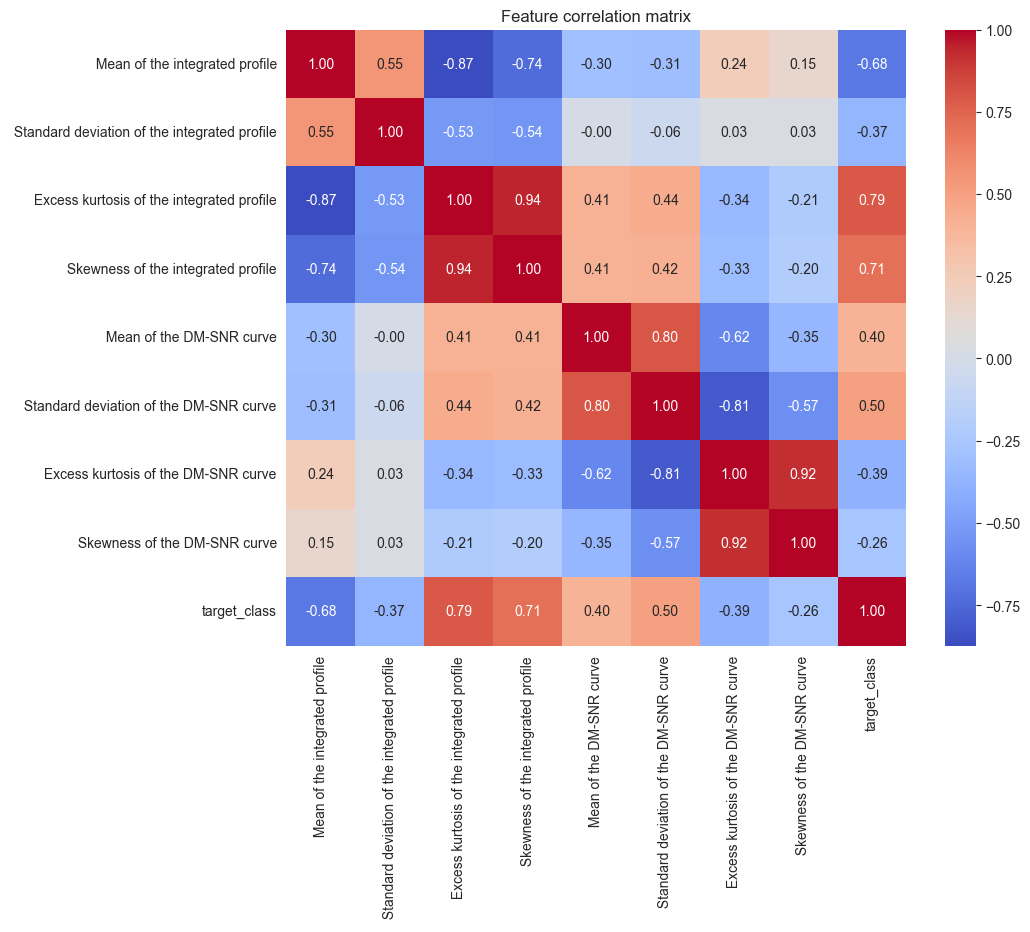

In [51]:
# macierz korelacji
# wartości bliskie 0 -> brak powiązania, bliskie 1 lub -1 -> bardzo silne powiązanie między cechami

plt.figure(figsize=(10, 8))
sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature correlation matrix")
plt.show()

- największy wpływ na wykrywanie pulsarów -> kurtoza i średnia profilu
- wysoka korelacja między niektórymi cechami -> powtarzalność informacji (np Excess kurtosis i Skewness)

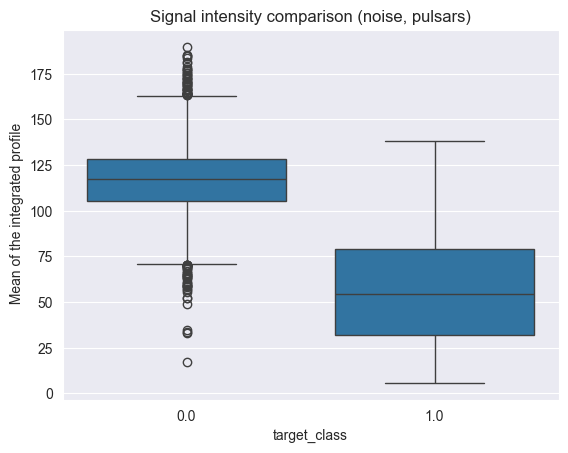

In [52]:
sns.boxplot(x='target_class', y=' Mean of the integrated profile', data=train_df)
plt.title("Signal intensity comparison (noise, pulsars)")
plt.show()

- pulsary (1) -> niższa średnia intensywność niż szum (0)

## Dataset and DataLoader

## MLP Network Architecture

## Training Loop

## Evaluation and Results